# 🏠 House Price Prediction — ACP & Clustering EM
## Objectif
Appliquer une ACP pour réduire la dimension des données,
puis utiliser l'algorithme EM (mélanges gaussiens) pour 
identifier des groupes de maisons similaires.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Charger les données preprocessées
X = pd.read_csv('../data/processed/X_scaled.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()

print("Données chargées :", X.shape)

Données chargées : (1458, 259)


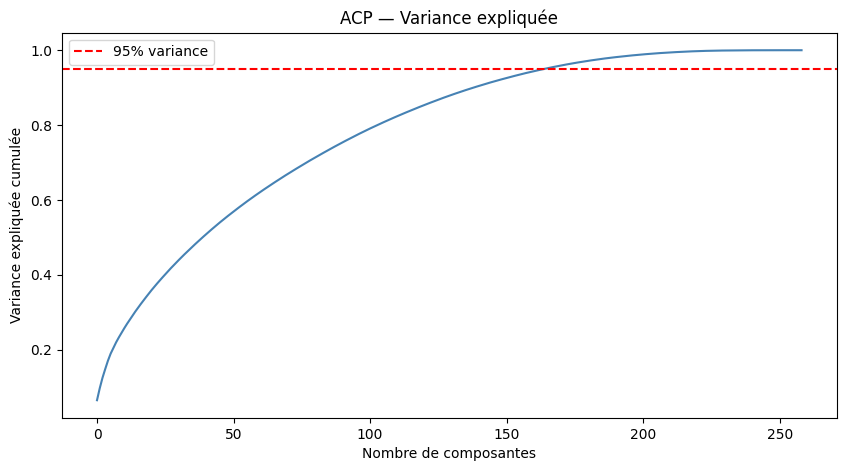

In [2]:
# ACP — réduction de dimension
pca = PCA()
pca.fit(X)

# Variance expliquée cumulée
variance_cumulee = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(variance_cumulee, color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('ACP — Variance expliquée')
plt.legend()
plt.show()

In [3]:
# Appliquer l'ACP avec 150 composantes
n_components = np.argmax(variance_cumulee >= 0.95) + 1
print(f"Nombre de composantes pour 95% de variance : {n_components}")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)
print(f"Taille après ACP : {X_pca.shape}")

Nombre de composantes pour 95% de variance : 165
Taille après ACP : (1458, 165)


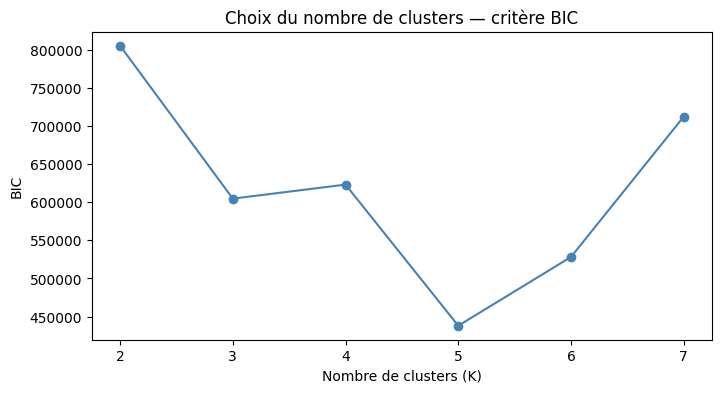

In [4]:
# Clustering EM — Mélanges Gaussiens
# On cherche le bon nombre de clusters avec le BIC
bic_scores = []
k_range = range(2, 8)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

plt.figure(figsize=(8, 4))
plt.plot(k_range, bic_scores, marker='o', color='steelblue')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('BIC')
plt.title('Choix du nombre de clusters — critère BIC')
plt.show()

C:\Users\amine\AppData\Local\Temp\ipykernel_28440\2986866255.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='SalePrice', data=df_original, palette='coolwarm')


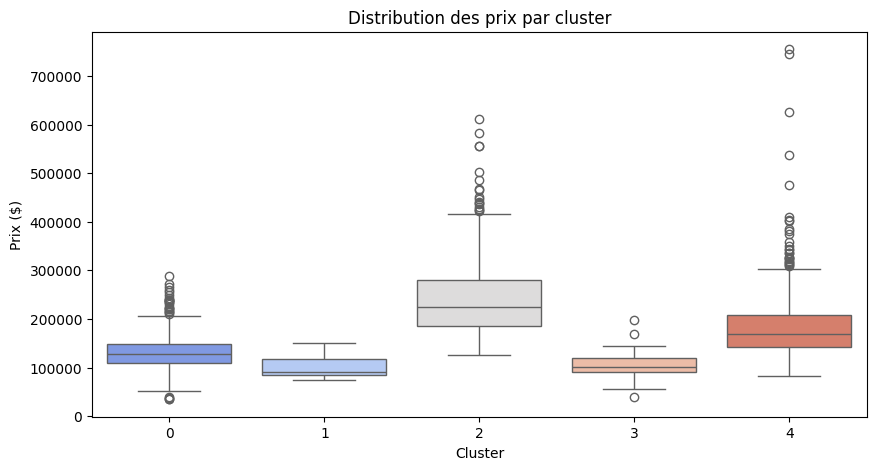

In [5]:
# Appliquer l'EM avec K=5
gmm = GaussianMixture(n_components=5, random_state=42)
clusters = gmm.fit_predict(X_pca)

# Ajouter les clusters au dataframe original
df_original = pd.read_csv('../data/train.csv')
df_original = df_original[~((df_original['GrLivArea'] > 4000) & 
                             (df_original['SalePrice'] < 200000))]
df_original['Cluster'] = clusters

# Visualiser les clusters par prix
plt.figure(figsize=(10, 5))
sns.boxplot(x='Cluster', y='SalePrice', data=df_original, palette='coolwarm')
plt.title('Distribution des prix par cluster')
plt.xlabel('Cluster')
plt.ylabel('Prix ($)')
plt.show()